[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dataguirre/Curso-IA-Aplicada/blob/main/Semana%2009-10_%20NLP_y_etica/fundamentos_nlp.ipynb)



# Fundamentos de NLP

In [16]:
!pip install gensim
!pip install pandarallel

  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=3991153397a61003871f8b070a439f444a855e4a8e29793534b7782d53cbacc3
  Stored in directory: /root/.cache/pip/wheels/46/f9/0d/40c9cd74a7cb8dc8fe57e8d6c3c19e2c730449c0d3f2bf66b5
Successfully built pandarallel


In [4]:
import re
import nltk
import pandas as pd
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# --- Descargas necesarias ---
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Base de datos Banco de la Republica

In [5]:
banrep = pd.read_csv('https://drive.google.com/uc?id=1vz3530nztdYPs-x0ZELlRPjNEcK453hc')
banrep

,uuid,name,collection,authors,type,date,abstract_spa,doi_link,access_rights,keywords,keywords_spa,jel,jel_spa,abstract
0,51ca64ae-e34d-46dd-9549-949c42d88abc,Informe de la Evolución de la Balanza de Pagos...,Informe de la Evolución de la Balanza de Pagos...,Subgerencia de Política Monetaria e Informació...,Report,2025-09-01,El resultado global de la balanza de pagos par...,https://doi.org/10.32468/balanzapagos.tr2-2025,Open Access,"Balance of payments, Macroeconomics, Inflation...","Balanza de pagos, Macroeconomía, Inflación, Po...","E - Macroeconomics and Monetary Economics, E20...","E - Macroeconomía y economía monetaria, E20 - ...",NaN
1,391ae845-d204-412f-badc-9de563aad423,Dynamic Balance Sheet Simulation and Credit De...,Borradores de Economía,"Cuesta-Mora, Diego Fernando, Gómez-Molina, And...",Working Paper,2025-08-29,Este documento presenta un modelo de prueba de...,https://doi.org/10.32468/be.1325,Open Access,"Stress Testing, Credit Risk, Credit Default, M...","Prueba de estrés, Riesgo crediticio, Incumplim...","G3 - Corporate Finance and Governance, G21 - B...","G3 - Gobierno y financiación de la empresa, G2...",This paper presents a stress test model used b...
2,1553960b-ef48-4960-b32b-78dd57d6396c,Report of the Board of Directors to the Congre...,Report of the Board of Directors to the Congre...,"Ávila-Plazas, Germán, Acosta-Navarro, Olga Luc...",Report,2025-08-27,NaN,https://doi.org/10.32468/inf-jun-dir-con-rep-e...,Open Access,"Inflation, Labour market, Interest rates, Mone...","Inflación, Mercado laboral, Tasas de interés, ...","E50 - Monetary Policy, Central Banking, and th...","E50 - Política monetaria, bancos centrales, of...","In the first months of 2025, annual inflation ..."
3,1286621c-3230-4b38-a97f-c1eaf58d2abc,Reporte de la Infraestructura Financiera e Ins...,Reporte de la Infraestructura Financiera e Ins...,"Gerencia Técnica, Vargas-Herrera, Hernando, Su...",Report,2025-08-26,"Desde 2010, el Banco de la República (Banrep) ...",https://doi.org/10.32468/rept-infr-finan.2025,Open Access,"Payment systems, Capital market, Liquidity, Fi...","Mercado de capitales, Liquidez, Riesgo financi...",E42 - Monetary Systems; Standards; Regimes; Go...,E42 - Sistemas monetarios; Patrones; Regímenes...,NaN
4,52fb80f5-6004-49d5-9eef-4f96184938a8,Crecimiento del empleo liderado por el área ru...,Reportes del Mercado Laboral,Subgerencia de Política Monetaria e Informació...,Report,2025-08-11,Según la Gran encuesta integrada de hogares (G...,https://doi.org/10.32468/rml.35,Open Access,"Employment, Workforce, Job, Wages, Colombia",NaN,E24 - Employment; Unemployment; Wages; Interge...,E24 - Empleo; Desempleo; Salarios; Distribució...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5741,3aed7302-bbde-4b28-a729-c12a74825980,Publicaciones Académicas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5742,b8a7d6d7-7843-44d2-a1f0-4ec656b0ab67,"Reportes, Boletines e Informes",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5743,f282f4b4-f0d0-4235-83d4-4d7a834071af,La economía de las ciénagas del Caribe colombiano,Libros Banco de la República,"Viloria-de-la-Hoz, Joaquín, Salazar-Mejía, Irene",Book,2011-08-01,La región Caribe cuenta con una gran riqueza e...,https://doi.org/10.32468/Ebook.664-245-3,Open Access,"Socio-economic aspects, Regional bibliography,...","Aspectos socioeconómicos, Bibliografía regiona...","P25 - Urban, Rural, and Regional Economics, P4...","P25 - Economía urbana, rural y regional, P43 -...",NaN
5744,fdeb9d11-91c6-445d-a925-c2ae9702a849,Applying CoV aR to measure systemic market ris...,Temas de Estabilidad Financiera,"Arias, Mauricio, Mendoza-Gutiérrez, Juan Carlo...",Working Paper,2010-03-01,NaN,https://doi.org/10.32468/tef.47,Open Access,"Systemic Market Risk, CoV aR, Value at Risk, Q...","Riesgo sistémico de mercado, CoV aR, Valor en ...",C20 - Single Equation Models; Single Variables...,C20 - Modelos uniecuacionales; variables simpl...,"In Colombia, the exposition to market risk has..."


In [6]:
columns = ['uuid', 'name', 'collection', 'authors', 'type', 'date', 'abstract_spa',
           'doi_link', 'access_rights', 'access_rights', 'keywords_spa', 'jel_spa']

banrep = banrep[(~banrep['abstract_spa'].isna()) & (~banrep['authors'].isna())][columns].reset_index(drop=True)
banrep

,uuid,name,collection,authors,type,date,abstract_spa,doi_link,access_rights,access_rights,keywords_spa,jel_spa
0,51ca64ae-e34d-46dd-9549-949c42d88abc,Informe de la Evolución de la Balanza de Pagos...,Informe de la Evolución de la Balanza de Pagos...,Subgerencia de Política Monetaria e Informació...,Report,2025-09-01,El resultado global de la balanza de pagos par...,https://doi.org/10.32468/balanzapagos.tr2-2025,Open Access,Open Access,"Balanza de pagos, Macroeconomía, Inflación, Po...","E - Macroeconomía y economía monetaria, E20 - ..."
1,391ae845-d204-412f-badc-9de563aad423,Dynamic Balance Sheet Simulation and Credit De...,Borradores de Economía,"Cuesta-Mora, Diego Fernando, Gómez-Molina, And...",Working Paper,2025-08-29,Este documento presenta un modelo de prueba de...,https://doi.org/10.32468/be.1325,Open Access,Open Access,"Prueba de estrés, Riesgo crediticio, Incumplim...","G3 - Gobierno y financiación de la empresa, G2..."
2,1286621c-3230-4b38-a97f-c1eaf58d2abc,Reporte de la Infraestructura Financiera e Ins...,Reporte de la Infraestructura Financiera e Ins...,"Gerencia Técnica, Vargas-Herrera, Hernando, Su...",Report,2025-08-26,"Desde 2010, el Banco de la República (Banrep) ...",https://doi.org/10.32468/rept-infr-finan.2025,Open Access,Open Access,"Mercado de capitales, Liquidez, Riesgo financi...",E42 - Sistemas monetarios; Patrones; Regímenes...
3,52fb80f5-6004-49d5-9eef-4f96184938a8,Crecimiento del empleo liderado por el área ru...,Reportes del Mercado Laboral,Subgerencia de Política Monetaria e Informació...,Report,2025-08-11,Según la Gran encuesta integrada de hogares (G...,https://doi.org/10.32468/rml.35,Open Access,Open Access,NaN,E24 - Empleo; Desempleo; Salarios; Distribució...
4,99adbb59-b20a-4161-a63d-e6181a3e0e1b,Encuesta de percepción sobre riesgos del siste...,Informe de Encuesta de Percepción Sobre Riesgo...,"Casas-Fajardo, Andrés Esteban, Cuesta-Mora, Di...",Report,2025-08-08,En este informe se presentan los resultados de...,https://doi.org/10.32468/eprf.sem2-2025,Open Access,Open Access,"Percepción de riesgos, Sistema financiero, Enc...",G20 - Instituciones y servicios financieros: G...
...,...,...,...,...,...,...,...,...,...,...,...,...
4967,d87c237c-76f8-4f72-9872-a0fd3386e788,Economías del Pacífico colombiano,Libros Banco de la República,"Bonet-Morón, Jaime, Pérez-Valbuena, Gerson Jav...",Book,2008-07-01,En el Centro de Estudios Económicos Regionales...,https://doi.org/10.32468/Ebook.664-204-0,Open Access,Open Access,"Actividad portuaria, CEER, Condiciones económi...","I30 - Bienestar y pobreza: Generalidades, O18 ..."
4968,e974699b-ff27-4051-a93e-5afecb10daa3,Enfermedad holandesa y exportaciones de banano...,Cuadernos de Historia Económica,"Meisel-Roca, Adolfo",Working Paper,2010-04-01,Una de las principales causas para el limitado...,https://doi.org/10.32468/chee.26,Open Access,Open Access,"Enfermedad holandesa, Economía regional, Banano",R10 - Economía regional general: Generalidades...
4969,e5ad4bcc-7abb-4551-9110-d5d07297e31c,Las economías departamentales del Caribe conti...,Libros Banco de la República,"Bonet-Morón, Jaime, Pérez-Valbuena, Gerson Jav...",Book,2007-12-01,En este libro se recogen los trabajos monográf...,https://doi.org/10.32468/Ebook.664-201-9,Open Access,Open Access,"Capital humano, CEER, Condiciones económicas, ...","O10 - Desarrollo económico, innovación, cambio..."
4970,df0e9800-b25b-495b-91a5-b8e246b8f850,Banco de la República : 90 años de la Banca Ce...,Libros Banco de la República,"Uribe, José Darío, Drake, Paul W., Kalmanovitz...",Book,2013-07-01,Libro conmemorativo por el aniversario número ...,https://doi.org/10.32468/Ebook.664-284-2,Open Access,Open Access,"Aniversarios, Banco de la República, Bancos ce...","E58 - Bancos centrales y sus políticas, E59 - ..."


# Preprocesamiento de texto

### Algunos operadores

<div> <center>

| **RE** | **Expansión** |                          **Patrón capturado**                         |
|:------:|:-------------:|:---------------------------------------------------------------------:|
|   \d   |     [0-9]     |                            Cualquier dígito                           |
|   \D   |     [^0-9]    |                          Cualquier no dígito                          |
|   \w   |  [a-zA-Z0-9_] |                  Cualquier alfanumérico o guion bajo                  |
|   \W   |     [ˆ\w]     |                 Cualquier no alfanumérico o guion bajo                |
|   \s   |  [ \r\t\n\f]  |                           Espacio en blanco                           |
|   \S   |     [ˆ\s]     |                        No un espacio en blanco                        |
|    *   |               |         Cero o más ocurrencias del caracter o expresión pasada        |
|    +   |               |         Una o más ocurrencias del caracter o expresión pasada         |
|    ?   |               | Exactamente cero o una ocurrencia del del caracter o expresión pasada |
|   {n}  |               |            *n* ocurrencias del caracter o expresión pasada            |
|  {n,m} |               |        De *n* a *m* ocurrencias del caracter o expresión pasada       |
|  {n,}  |               |      Por lo menos *n* ocurrencias del caracter o expresión pasada     |
|  {,m}  |               |         Hasta *m* ocurrencias del caracter o expresión pasada         |

</div> </center>

In [7]:
# --- Recursos globales ---
STOPWORDS_ES = set(stopwords.words("spanish")) | {
    "doi", "http", "https", "www", "et", "al", "etc"
}
STEMMER_ES = SnowballStemmer("spanish")

# Mapa para quitar acentos (manteniendo ñ)
_ACCENT_MAP = str.maketrans("áéíóúüÁÉÍÓÚÜ", "aeiouuAEIOUU")

# Expresiones regulares útiles
_URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
_NUM_SYM = re.compile(r"[0-9]+|[_/#%€$£°ºª©™®§]")
_TOKEN_RE = re.compile(r"[a-zñ]+")

In [8]:
def normalizacion(texto):
    """
    Normaliza texto en español:
    - Minúsculas
    - Quita URLs, emails, números y símbolos
    - Elimina tildes y diéresis (mantiene ñ)
    - Colapsa espacios múltiples
    """
    if not isinstance(texto, str):
        return ""
    t = texto.strip().lower()
    t = _URL_RE.sub(" ", t)
    t = _EMAIL_RE.sub(" ", t)
    t = _NUM_SYM.sub(" ", t)
    t = t.translate(_ACCENT_MAP)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def tokenizar_texto(texto):
    """
    Tokeniza extrayendo palabras (incluye ñ).
    """
    t = normalizacion(texto)
    return _TOKEN_RE.findall(t)

def eliminar_stopwords(tokens):
    """
    Elimina stopwords en español.
    """
    return [w for w in tokens if w not in STOPWORDS_ES and len(w) > 1]

def stemmizar(tokens):
    """
    Aplica stemming en español usando SnowballStemmer.
    """
    return [STEMMER_ES.stem(w) for w in tokens]

def preprocesamiento(texto):
    """
    Pipeline completo: normaliza → tokeniza → quita stopwords → stemming.
    Devuelve lista de tokens procesados.
    """
    tokens = tokenizar_texto(texto)
    tokens = eliminar_stopwords(tokens)
    tokens = stemmizar(tokens)
    return tokens

In [9]:
ejemplo = banrep['abstract_spa'].iloc[0]
print("Texto original: \n")
print(ejemplo)

Texto original: 

El resultado global de la balanza de pagos para el segundo trimestre de 2025 registra un déficit en cuenta corriente de USD 2.595 millones (m) equivalente a 2,5% del PIB trimestral, superior en US$ 504 m y en 0,50 puntos porcentuales (pp.) del PIB con respecto al trimestre inmediatamente anterior.

Por su parte, la cuenta financiera registró entradas netas de capital por US$ 1.924 m equivalentes a 1,8% del PIB trimestral, superiores en USD 310 m y en 0,3 pp. del PIB frente a lo reportado un trimestre atrás. Se estimaron errores y omisiones por US$ 671 m.

Con respecto al primer semestre de 2024, el déficit corriente fue superior en US$ 1.407 m y en 0,6 pp. del PIB. A su vez, la cuenta financiera, registró mayores entradas netas de capital en US$ 841 m y en 0,4 pp. del PIB frente a lo reportado un año atrás.

Con el propósito de suministrar información que permita comprender con mayor claridad la evolución reciente del sector externo colombiano, este boletín contiene t

In [10]:
# Normalización
ejemplo_norm = normalizacion(ejemplo)
print("Texto normalizado:")
print(ejemplo_norm, "\n")

Texto normalizado:
el resultado global de la balanza de pagos para el segundo trimestre de registra un deficit en cuenta corriente de usd . millones (m) equivalente a , del pib trimestral, superior en us m y en , puntos porcentuales (pp.) del pib con respecto al trimestre inmediatamente anterior. por su parte, la cuenta financiera registro entradas netas de capital por us . m equivalentes a , del pib trimestral, superiores en usd m y en , pp. del pib frente a lo reportado un trimestre atras. se estimaron errores y omisiones por us m. con respecto al primer semestre de , el deficit corriente fue superior en us . m y en , pp. del pib. a su vez, la cuenta financiera, registro mayores entradas netas de capital en us m y en , pp. del pib frente a lo reportado un año atras. con el proposito de suministrar informacion que permita comprender con mayor claridad la evolucion reciente del sector externo colombiano, este boletin contiene tres partes: la primera describe la evolucion de la balanza 

In [11]:
# Tokenización
ejemplo_tokens = tokenizar_texto(ejemplo)
print("Tokens:")
print(' '.join(ejemplo_tokens), "\n")

Tokens:
el resultado global de la balanza de pagos para el segundo trimestre de registra un deficit en cuenta corriente de usd millones m equivalente a del pib trimestral superior en us m y en puntos porcentuales pp del pib con respecto al trimestre inmediatamente anterior por su parte la cuenta financiera registro entradas netas de capital por us m equivalentes a del pib trimestral superiores en usd m y en pp del pib frente a lo reportado un trimestre atras se estimaron errores y omisiones por us m con respecto al primer semestre de el deficit corriente fue superior en us m y en pp del pib a su vez la cuenta financiera registro mayores entradas netas de capital en us m y en pp del pib frente a lo reportado un año atras con el proposito de suministrar informacion que permita comprender con mayor claridad la evolucion reciente del sector externo colombiano este boletin contiene tres partes la primera describe la evolucion de la balanza de pagos en el segundo trimestre de frente a lo ocu

In [12]:
# Eliminación de stopwords
ejemplo_nosw = eliminar_stopwords(ejemplo_tokens)
print("Sin stopwords:")
print(' '.join(ejemplo_nosw), "\n")

Sin stopwords:
resultado global balanza pagos segundo trimestre registra deficit cuenta corriente usd millones equivalente pib trimestral superior us puntos porcentuales pp pib respecto trimestre inmediatamente anterior parte cuenta financiera registro entradas netas capital us equivalentes pib trimestral superiores usd pp pib frente reportado trimestre atras estimaron errores omisiones us respecto primer semestre deficit corriente superior us pp pib vez cuenta financiera registro mayores entradas netas capital us pp pib frente reportado año atras proposito suministrar informacion permita comprender mayor claridad evolucion reciente sector externo colombiano boletin contiene tres partes primera describe evolucion balanza pagos segundo trimestre frente ocurrido trimestre inmediatamente anterior segunda parte presenta resultados primer semestre frente mismo periodo tercera parte resumen resultados posicion inversion internacional pais corte junio 



In [13]:
# Stemming
ejemplo_stem = stemmizar(ejemplo_nosw)
print("Con stemming:")
print(' '.join(ejemplo_stem))

Con stemming:
result global balanz pag segund trimestr registr deficit cuent corrient usd millon equivalent pib trimestral superior us punt porcentual pp pib respect trimestr inmediat anterior part cuent financ registr entrad net capital us equivalent pib trimestral superior usd pp pib frent report trimestr atras estim error omision us respect prim semestr deficit corrient superior us pp pib vez cuent financ registr mayor entrad net capital us pp pib frent report año atras proposit suministr inform permit comprend mayor clarid evolucion recient sector extern colombian boletin contien tres part primer describ evolucion balanz pag segund trimestr frent ocurr trimestr inmediat anterior segund part present result prim semestr frent mism period tercer part resum result posicion inversion internacional pais cort juni


In [14]:
tqdm.pandas(desc="Preprocesando abstracts ES")
banrep["tokens_clean"] = (
    banrep["abstract_spa"]
    .fillna("")
    .astype(str)
    .progress_apply(preprocesamiento)
)

Preprocesando abstracts ES: 100%|██████████| 4972/4972 [00:21<00:00, 226.00it/s]


**Paralelizacion?**

La **paralelización** consiste en dividir un conjunto de tareas en varios procesos que se ejecutan **simultáneamente** en distintos núcleos del procesador (CPUs).  
En lugar de procesar cada texto de forma secuencial con un solo hilo, el sistema reparte el trabajo entre varios *workers* que operan en paralelo, reduciendo significativamente el tiempo total de ejecución.

En tareas como el **preprocesamiento de texto**, esta técnica resulta especialmente eficaz porque cada observación (por ejemplo, cada *abstract*) se puede limpiar o tokenizar **de manera independiente** del resto.  
Esa independencia permite distribuir las operaciones entre múltiples núcleos sin riesgo de conflictos o dependencia entre procesos.

En este ejemplo, la librería `pandarallel` divide el `DataFrame` en fragmentos, los envía a los *workers* disponibles y combina los resultados al finalizar, mostrando además una barra de progreso.  
Gracias a esto, el preprocesamiento se completa **en una fracción del tiempo** comparado con el uso tradicional de `apply` o `progress_apply`.

En resumen:  
- Aprovecha todos los núcleos disponibles del CPU.  
- Reduce tiempos en tareas repetitivas e independientes.  
- Es ideal para pipelines de limpieza o tokenización de texto.

In [20]:
from pandarallel import pandarallel
import os
import time

print(f'CPUs: {os.cpu_count()}')

CPUs: 2


In [21]:
workers = 2
pandarallel.initialize(progress_bar=True, nb_workers=workers)

start_time = time.time()

banrep["tokens_clean"] = (
    banrep["abstract_spa"]
    .fillna("")
    .astype(str)
    .parallel_apply(preprocesamiento)
)

end_time = time.time()
elapsed = end_time - start_time

print(f"Preprocesamiento completado en {elapsed:.2f} segundos")

INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


Preprocesamiento completado en 15.05 segundos


# Nube de Palabras

Con nuestro texto normalizado, podemos hacer un análisis sencillo del texto usando nubes de palabras. Las nubes de palabras (también conocidas como "word clouds" en inglés) son representaciones visuales de un conjunto de palabras en un texto, donde el tamaño de cada palabra se determina en función de su frecuencia de aparición en el texto. Es una forma popular y efectiva de visualizar la distribución y relevancia de las palabras en un documento.

La librería `WordCloud` en `Python` es una herramienta ampliamente utilizada para crear nubes de palabras de manera sencilla. La función principal de `WordCloud` es tomar un texto y generar una nube de palabras donde el tamaño de cada palabra se determina por su frecuencia en el texto.

In [69]:
tqdm.pandas(desc="Preprocesando abstracts ES")
banrep["tokenizar"] = (
    banrep["abstract_spa"]
    .fillna("")
    .astype(str)
    .progress_apply(tokenizar_texto)
)
docs_tokens = banrep['tokenizar'].dropna().tolist()
text = " ".join(" ".join(doc) for doc in docs_tokens)

Preprocesando abstracts ES: 100%|██████████| 4972/4972 [00:02<00:00, 2245.71it/s]


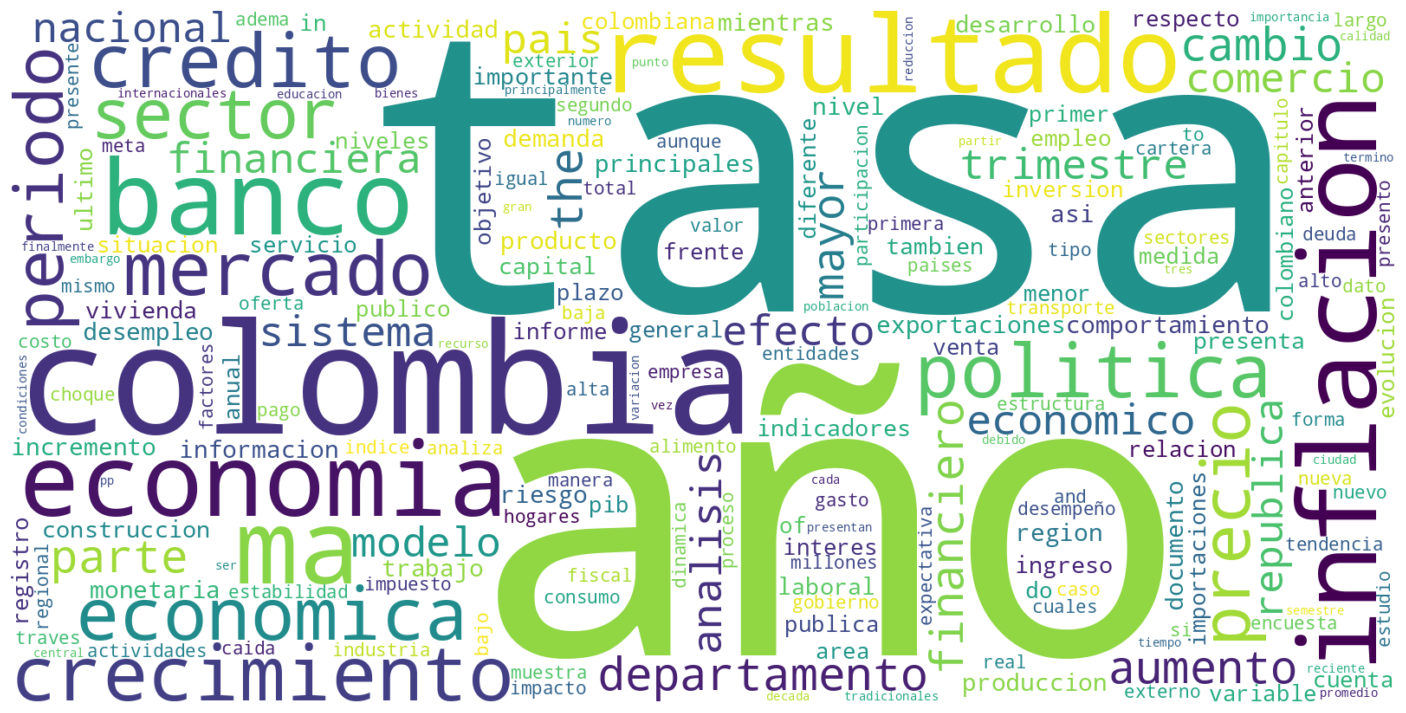

In [71]:
# 3) Crear y mostrar la nube
wc = WordCloud(
    width=1600, height=800,
    background_color="white",
    stopwords=STOPWORDS_ES,
    collocations=False  # evita juntar palabras comunes que no quieres
).generate(text)

plt.figure(figsize=(18,9))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

Detectando bigramas: 100%|██████████| 4972/4972 [00:00<00:00, 7549.01it/s]


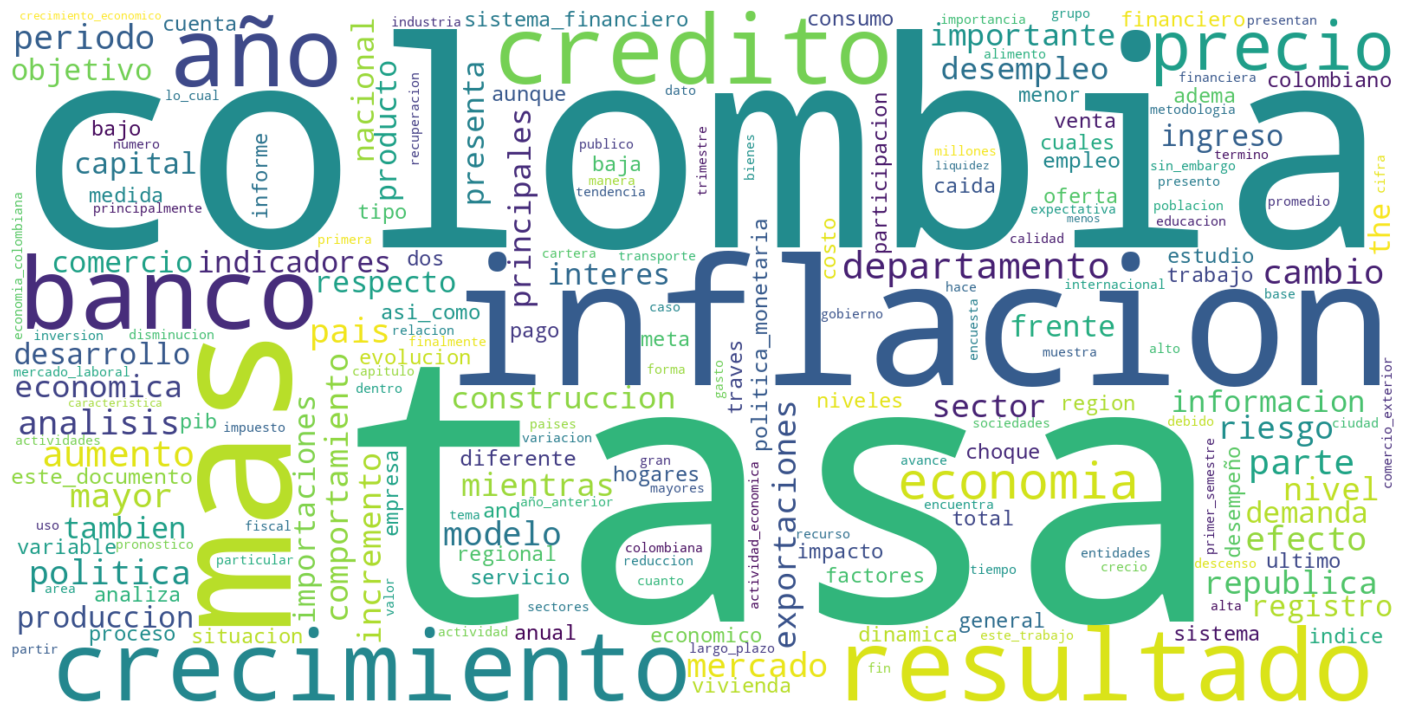

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from gensim.models.phrases import Phrases, Phraser
from tqdm import tqdm


docs = banrep["tokenizar"].dropna().tolist()

# ------------------------------------------------------------
# Detectar bigramas frecuentes con Gensim
# ------------------------------------------------------------
# min_count: número mínimo de veces que un par debe aparecer
# threshold: entre más alto, menos bigramas (ajusta según corpus)
bigram_model = Phrases(docs, min_count=10, threshold=20)
bigram_phraser = Phraser(bigram_model)

# Aplicar el modelo a todos los documentos
docs_with_bigrams = [bigram_phraser[doc] for doc in tqdm(docs, desc="Detectando bigramas")]

# ------------------------------------------------------------
# Aplanar todo el corpus a una sola lista de tokens
# ------------------------------------------------------------
tokens_flat = [token for doc in docs_with_bigrams for token in doc]

# Opcional: eliminar tokens muy cortos o numéricos
tokens_flat = [t for t in tokens_flat if len(t) > 2 and not t.isnumeric()]

# ------------------------------------------------------------
# Generar el texto completo para la nube
# ------------------------------------------------------------
text = " ".join(tokens_flat)

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    stopwords=STOPWORDS_ES,
    collocations=False,   # evita duplicar bigramas automáticos
    max_words=200
).generate(text)

plt.figure(figsize=(18,9))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# TF-IDF

$$
tf-idf_{ij}=tf_{ij} \times \left( \log \left( \frac{1+N}{1+df_i} \right)+1\right)
$$

donde:

- $tf_{ij}$ es la frecuencia palabra $i$ en el documento $j$
- $df_{ij}$ es el número de documentos que contienen la palabra $i$
- $N$ es el número de documentos

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def tokenizer_es(x):
    return preprocesamiento(x)

vectorizer = TfidfVectorizer(
    tokenizer=tokenizer_es,
    preprocessor=lambda x: x,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    sublinear_tf=True,
    dtype=np.float32
)

X_tfidf = vectorizer.fit_transform(banrep["abstract_spa"].fillna("").astype(str))
feat_names = vectorizer.get_feature_names_out()
print("Dimensión TF-IDF:", X_tfidf.shape)

Dimensión TF-IDF: (4972, 16884)


In [14]:
X_tfidf

<4972x16884 sparse matrix of type '<class 'numpy.float32'>'
	with 480705 stored elements in Compressed Sparse Row format>

In [61]:
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from gensim import matutils
import numpy as np

# Hacemos nuestro corpus de documentos en una lista
texts = banrep["tokens_clean"].tolist()

# Creamos un diccionario de palabras unicas
dictionary = Dictionary(texts)

# Ajusta estos umbrales a tu tamaño de corpus
dictionary.filter_extremes(no_below=5, no_above=0.85)  # >=5 docs, <=85% de docs
dictionary.compactify()

# BoW (lista de listas de (term_id, count))
corpus_bow = [dictionary.doc2bow(doc) for doc in texts]

print(dictionary.token2id)

{'anterior': 0, 'atras': 1, 'año': 2, 'balanz': 3, 'boletin': 4, 'capital': 5, 'clarid': 6, 'colombian': 7, 'comprend': 8, 'contien': 9, 'corrient': 10, 'cort': 11, 'cuent': 12, 'deficit': 13, 'describ': 14, 'entrad': 15, 'equivalent': 16, 'error': 17, 'estim': 18, 'evolucion': 19, 'extern': 20, 'financ': 21, 'frent': 22, 'global': 23, 'inform': 24, 'inmediat': 25, 'internacional': 26, 'inversion': 27, 'juni': 28, 'mayor': 29, 'millon': 30, 'mism': 31, 'net': 32, 'ocurr': 33, 'omision': 34, 'pag': 35, 'pais': 36, 'part': 37, 'period': 38, 'permit': 39, 'pib': 40, 'porcentual': 41, 'posicion': 42, 'pp': 43, 'present': 44, 'prim': 45, 'primer': 46, 'proposit': 47, 'punt': 48, 'recient': 49, 'registr': 50, 'report': 51, 'respect': 52, 'result': 53, 'resum': 54, 'sector': 55, 'segund': 56, 'semestr': 57, 'suministr': 58, 'superior': 59, 'tercer': 60, 'tres': 61, 'trimestr': 62, 'trimestral': 63, 'us': 64, 'usd': 65, 'vez': 66, 'advers': 67, 'aport': 68, 'apoy': 69, 'balanc': 70, 'banc': 71

In [62]:
# 4) TF-IDF con Gensim (streaming-friendly)
#    smartirs='ntc' aplica una variante estándar de normalización
tfidf_model = TfidfModel(corpus_bow, smartirs='ntc', normalize=True)
corpus_tfidf = tfidf_model[corpus_bow]  # iterable de listas (term_id, tfidf)

# 5) OPCIONAL: convertir a matriz SciPy CSR para ML downstream
#    (filas = documentos, columnas = términos)
X_tfidf_csr = matutils.corpus2csc(corpus_tfidf, num_terms=len(dictionary)).T.tocsr()

print("Dimensión TF-IDF:", X_tfidf_csr.shape)  # (n_docs, n_terms)

# 6) OPCIONAL: nombres de características (vocabulario)
feature_names = [dictionary[i] for i in range(len(dictionary))]

# 7) Ejemplo: top-10 términos por documento 0
doc_id = 0
row = X_tfidf_csr.getrow(doc_id)
top_idx = np.argsort(row.data)[::-1][:10]
top_terms = [(feature_names[row.indices[i]], float(row.data[i])) for i in top_idx]
print("Top términos doc 0:", top_terms)

Dimensión TF-IDF: (4972, 4063)
Top términos doc 0: [('us', 0.40844362720149113), ('pib', 0.30759367375312463), ('pp', 0.2888643720363029), ('usd', 0.2189381301372636), ('trimestr', 0.19440073498755275), ('frent', 0.1857273695463137), ('equivalent', 0.1826698240172209), ('inmediat', 0.17218355190073115), ('superior', 0.17126340739254928), ('entrad', 0.16418045302677084)]


# Distancia del coseno

In [63]:
from gensim.similarities import MatrixSimilarity
import numpy as np

# Crear índice de similitud TF-IDF
index = MatrixSimilarity(corpus_tfidf, num_features=len(dictionary))

# Definir función de búsqueda
def buscar_documentos(query, top_n=5):
    """
    Busca en el corpus los documentos más similares a la query.
    Imprime título, similitud y fragmento del abstract.
    """
    # Preprocesar la consulta (igual que los textos del corpus)
    tokens = preprocesamiento(query)
    bow = dictionary.doc2bow(tokens)
    tfidf_vec = tfidf_model[bow]

    # Calcular similitud coseno entre query y documentos
    sims = index[tfidf_vec]  # vector de similitudes

    # Top-N documentos más similares
    top_idx = np.argsort(sims)[::-1][:top_n]
    resultados = []
    for i in top_idx:
        print(f"{banrep.loc[i, 'name']}")
        print(f"   Similitud: {float(sims[i]):.4f}")
        print(f"   Extracto: {banrep.loc[i, 'abstract_spa'][:600].strip()}\n")
        print(f"   UUID: {banrep.loc[i, 'uuid']}\n")
        print("-" * 100)

        resultados.append({
            "id": i,
            "titulo": banrep.loc[i, "name"],
            "similitud": float(sims[i]),
            "texto": banrep.loc[i, "abstract_spa"][:600].strip(),
            "link": banrep.loc[i, "doi_link"],
            "uuid": banrep.loc[i, "uuid"]
        })
    return resultados

In [59]:
# impacto de la política monetaria en la inflación colombiana
# evaluacion de impacto
# economía de Suroccidente
# balanza de pagos
# evolucion del endeudamiento externo
# consumo de los hogares

from ipywidgets import interact, Text, IntSlider

def demo_busqueda(q, k):
    res = buscar_documentos(q, top_n=k)

interact(
    demo_busqueda,
    q=Text(value="regla fiscal", description="Query:"),
    k=IntSlider(value=5, min=1, max=15, step=1, description="Top-N")
);

interactive(children=(Text(value='regla fiscal', description='Query:'), IntSlider(value=5, description='Top-N'…

# Machine learning

In [36]:
banrep[banrep['uuid'] == '54b8488b-c6e8-4bd1-837f-76ec68d7adec']['abstract_spa'].iloc[0]

'Descripción de las actividades y publicaciones del Centro de Estudios Económicos Regionales en la región caribe colombiana.'

In [34]:
banrep[banrep['uuid'] == '54b8488b-c6e8-4bd1-837f-76ec68d7adec']['tokens_clean'].iloc[0]

['descripcion',
 'activ',
 'public',
 'centr',
 'estudi',
 'econom',
 'regional',
 'region',
 'carib',
 'colombian']

In [32]:
banrep

,uuid,name,collection,authors,type,date,abstract_spa,doi_link,access_rights,access_rights,keywords_spa,jel_spa,tokens_clean
0,51ca64ae-e34d-46dd-9549-949c42d88abc,Informe de la Evolución de la Balanza de Pagos...,Informe de la Evolución de la Balanza de Pagos...,Subgerencia de Política Monetaria e Informació...,Report,2025-09-01,El resultado global de la balanza de pagos par...,https://doi.org/10.32468/balanzapagos.tr2-2025,Open Access,Open Access,"Balanza de pagos, Macroeconomía, Inflación, Po...","E - Macroeconomía y economía monetaria, E20 - ...","[result, global, balanz, pag, segund, trimestr..."
1,391ae845-d204-412f-badc-9de563aad423,Dynamic Balance Sheet Simulation and Credit De...,Borradores de Economía,"Cuesta-Mora, Diego Fernando, Gómez-Molina, And...",Working Paper,2025-08-29,Este documento presenta un modelo de prueba de...,https://doi.org/10.32468/be.1325,Open Access,Open Access,"Prueba de estrés, Riesgo crediticio, Incumplim...","G3 - Gobierno y financiación de la empresa, G2...","[document, present, model, prueb, estres, empl..."
2,1286621c-3230-4b38-a97f-c1eaf58d2abc,Reporte de la Infraestructura Financiera e Ins...,Reporte de la Infraestructura Financiera e Ins...,"Gerencia Técnica, Vargas-Herrera, Hernando, Su...",Report,2025-08-26,"Desde 2010, el Banco de la República (Banrep) ...",https://doi.org/10.32468/rept-infr-finan.2025,Open Access,Open Access,"Mercado de capitales, Liquidez, Riesgo financi...",E42 - Sistemas monetarios; Patrones; Regímenes...,"[banc, republ, banrep, desarroll, funcion, seg..."
3,52fb80f5-6004-49d5-9eef-4f96184938a8,Crecimiento del empleo liderado por el área ru...,Reportes del Mercado Laboral,Subgerencia de Política Monetaria e Informació...,Report,2025-08-11,Según la Gran encuesta integrada de hogares (G...,https://doi.org/10.32468/rml.35,Open Access,Open Access,NaN,E24 - Empleo; Desempleo; Salarios; Distribució...,"[segun, gran, encuest, integr, hogar, geih, ma..."
4,99adbb59-b20a-4161-a63d-e6181a3e0e1b,Encuesta de percepción sobre riesgos del siste...,Informe de Encuesta de Percepción Sobre Riesgo...,"Casas-Fajardo, Andrés Esteban, Cuesta-Mora, Di...",Report,2025-08-08,En este informe se presentan los resultados de...,https://doi.org/10.32468/eprf.sem2-2025,Open Access,Open Access,"Percepción de riesgos, Sistema financiero, Enc...",G20 - Instituciones y servicios financieros: G...,"[inform, present, result, encuest, percepcion,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4967,d87c237c-76f8-4f72-9872-a0fd3386e788,Economías del Pacífico colombiano,Libros Banco de la República,"Bonet-Morón, Jaime, Pérez-Valbuena, Gerson Jav...",Book,2008-07-01,En el Centro de Estudios Económicos Regionales...,https://doi.org/10.32468/Ebook.664-204-0,Open Access,Open Access,"Actividad portuaria, CEER, Condiciones económi...","I30 - Bienestar y pobreza: Generalidades, O18 ...","[centr, estudi, econom, regional, ceer, banc, ..."
4968,e974699b-ff27-4051-a93e-5afecb10daa3,Enfermedad holandesa y exportaciones de banano...,Cuadernos de Historia Económica,"Meisel-Roca, Adolfo",Working Paper,2010-04-01,Una de las principales causas para el limitado...,https://doi.org/10.32468/chee.26,Open Access,Open Access,"Enfermedad holandesa, Economía regional, Banano",R10 - Economía regional general: Generalidades...,"[principal, caus, limit, desempeñ, econom, cos..."
4969,e5ad4bcc-7abb-4551-9110-d5d07297e31c,Las economías departamentales del Caribe conti...,Libros Banco de la República,"Bonet-Morón, Jaime, Pérez-Valbuena, Gerson Jav...",Book,2007-12-01,En este libro se recogen los trabajos monográf...,https://doi.org/10.32468/Ebook.664-201-9,Open Access,Open Access,"Capital humano, CEER, Condiciones económicas, ...","O10 - Desarrollo económico, innovación, cambio...","[libr, recog, trabaj, monograf, departament, c..."
4970,df0e9800-b25b-495b-91a5-b8e246b8f850,Banco de la República : 90 años de la Banca Ce...,Libros Banco de la República,"Uribe, José Darío, Drake, Paul W., Kalmanovitz...",Book,2013-07-01,L